## Import Data

In [1]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs
import numpy as np
import pandas as pd 

PATHIM = "data//cnd_large//images.csv" 
PATHLB = "data//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})


# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels["label"].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


In [2]:
from sklearn.model_selection import train_test_split

SEED = 42

#Use np arrays, and change size of labels to (10000,)
images = np.array(images)
labels = np.array(labels).ravel()

X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(
    images, labels, test_size=0.25, random_state=SEED, stratify=labels
)



## Scale Data

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_TRAIN_SCALED = scaler.fit_transform(X_TRAIN)
X_TEST_SCALED = scaler.transform(X_TEST)



## Filter Comparison (All 4096 Values)

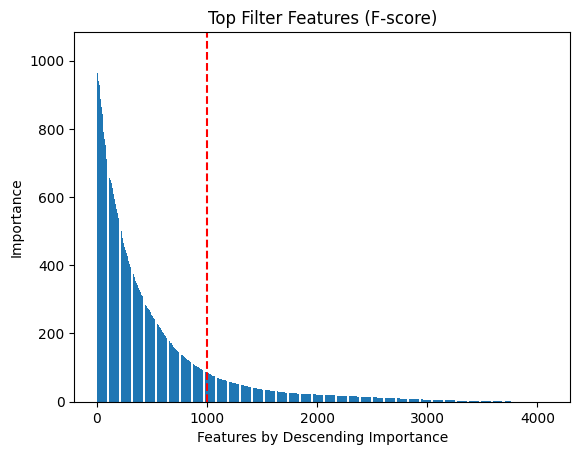

In [145]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
selector_all = SelectKBest(score_func=f_classif, k='all')
selector_all.fit(X_TRAIN_SCALED,Y_TRAIN)

f_scores = selector_all.scores_

asc_idx = np.argsort(f_scores)
desc_idx = asc_idx[::-1]


plt.figure()
plt.axvline(x=1000, color='red', linestyle='--')
plt.bar(range(4096), f_scores[desc_idx])
plt.title("Top Filter Features (F-score)")
plt.xlabel("Features by Descending Importance")
plt.ylabel("Importance")
plt.show()

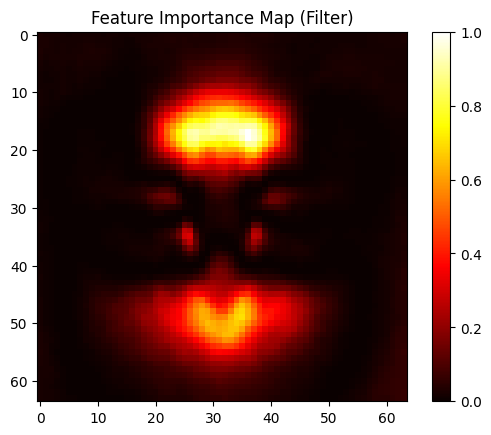

In [142]:
import matplotlib.pyplot as plt

importance = f_scores.reshape(64,64) 

importance = importance - importance.min()
importance = importance / importance.max()

img_shape = (64, 64)
importance_img = importance.reshape(img_shape)

plt.imshow(importance_img, cmap='hot')
plt.title("Feature Importance Map (Filter)")
plt.colorbar()
plt.show()

## Coeffs comparison only (Top 25 Values)

In [143]:
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression



feature_pipeline_25 = Pipeline([
    ('filter', SelectKBest(score_func=f_classif, k=25)),
    ('lasso', LogisticRegression(l1_ratio=1.0, solver='saga', max_iter=5000, random_state=SEED)),
])

In [144]:
C_values = np.logspace(-6, 2, 25)

# Store coefficients
coef_path = []

for C in C_values:

    feature_pipeline_25.set_params(lasso__C=C)

    feature_pipeline_25.fit(X_TRAIN, Y_TRAIN)

    coef = feature_pipeline_25.named_steps['lasso'].coef_.flatten()

    coef_path.append(coef)

coef_path = np.array(coef_path)

# Convert to lambda
lambda_values = 1 / C_values

KeyboardInterrupt: 

In [ ]:
print(len(coef_path[0]))
print(coef_path[0])

NameError: name 'coef_path' is not defined

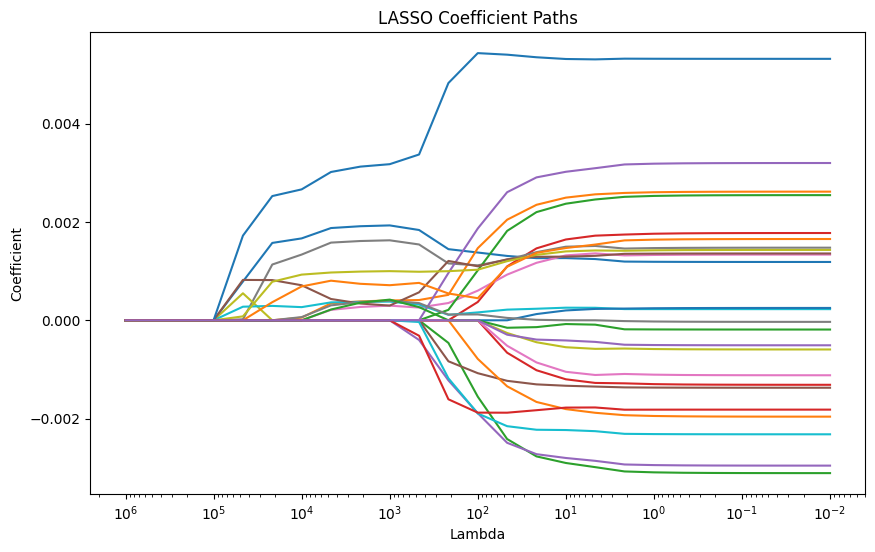

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for i in range(coef_path.shape[1]):
    plt.plot(lambda_values, coef_path[:, i])

plt.xscale('log')
plt.gca().invert_xaxis()

plt.xlabel('Lambda')
plt.ylabel('Coefficient')
plt.title('LASSO Coefficient Paths (Top 25 Parameters)')

plt.show()

# Lasso Only (No Filter) (C = .01)

In [148]:
logreg_all = LogisticRegression(l1_ratio=1.0,solver='saga', max_iter=5000, C = .01, random_state=SEED)

logreg_all.fit(X_TRAIN_SCALED, Y_TRAIN)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [147]:
coeffs_all = logreg_all.coef_ 


coeff_importance = coeffs_all.reshape(64,64)  # or filter_scores

coeff_importance = np.abs(coeff_importance)

img_shape = (64, 64)
importance_img = coeff_importance.reshape(img_shape)

plt.imshow(importance_img, cmap='hot')
plt.title("Feature Importance Map (C = .01 (lambda = 100))")
plt.colorbar()
plt.show()

NameError: name 'logreg_all' is not defined

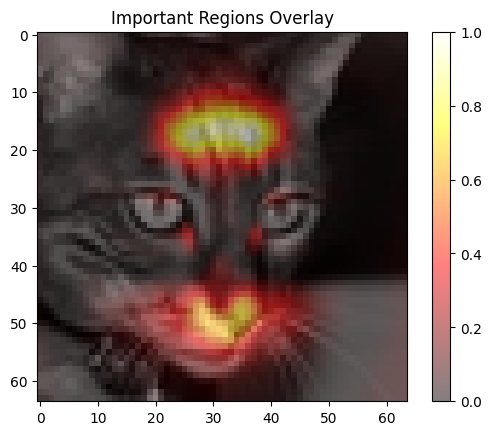

In [146]:
import random

sample_image = X_TRAIN_SCALED[random.randint(0,len(X_TRAIN_SCALED))]
sample_image = sample_image.reshape(64,64)

plt.imshow(sample_image, cmap='gray')
plt.imshow(importance_img, cmap='hot', alpha=0.5)
plt.title("Important Regions Overlay")
plt.colorbar()
plt.show()

## Different Cs on Lasso

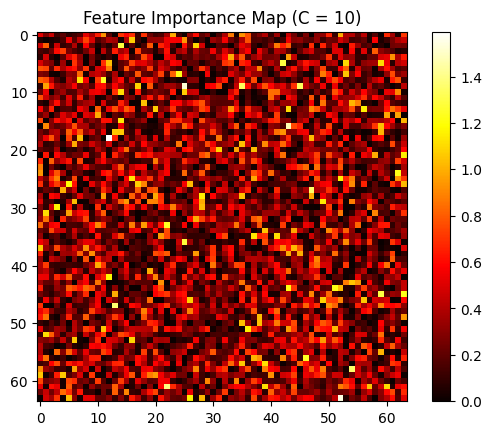

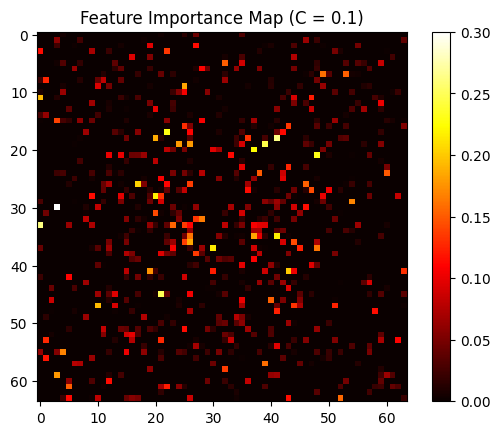

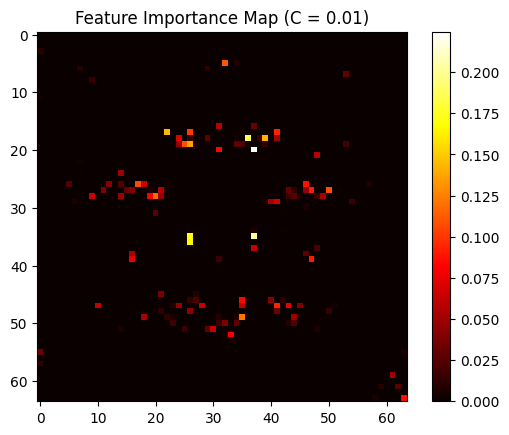

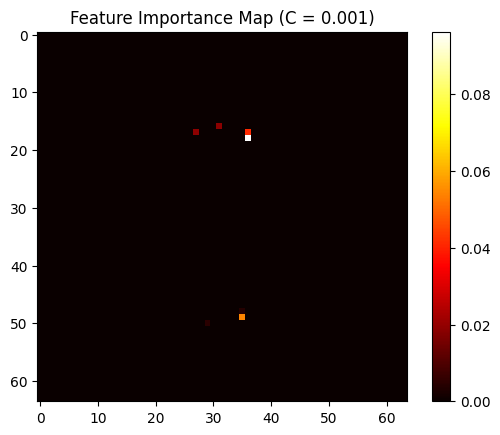

In [ ]:
from sklearn.linear_model import LogisticRegression


lasso_images = []

for Cval in [10,.1,.01,.001]:

    logreg_temp = LogisticRegression(l1_ratio=1.0,solver='saga', max_iter=5000, C = Cval)

    logreg_temp.fit(X_TRAIN_SCALED, Y_TRAIN)

    coeffs_temp = logreg_temp.coef_ 
    coeff_importance = coeffs_temp.reshape(64,64)  # or filter_scores

    coeff_importance = np.abs(coeff_importance)

    img_shape = (64, 64)
    importance_img = coeff_importance.reshape(img_shape)

    lasso_images.append(importance_img)

    plt.imshow(importance_img, cmap='hot')
    plt.title(f"Feature Importance Map (C = {Cval})")
    plt.colorbar()
    plt.show()

    

### Import Results (SEED = 42)

In [ ]:
grid_scores = pd.read_csv("./results_seed42/P2.02_grid_scores.csv", sep=",")

results = pd.DataFrame(grid_scores)
grouped_results = results.groupby(["dataset","classifier"])


ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

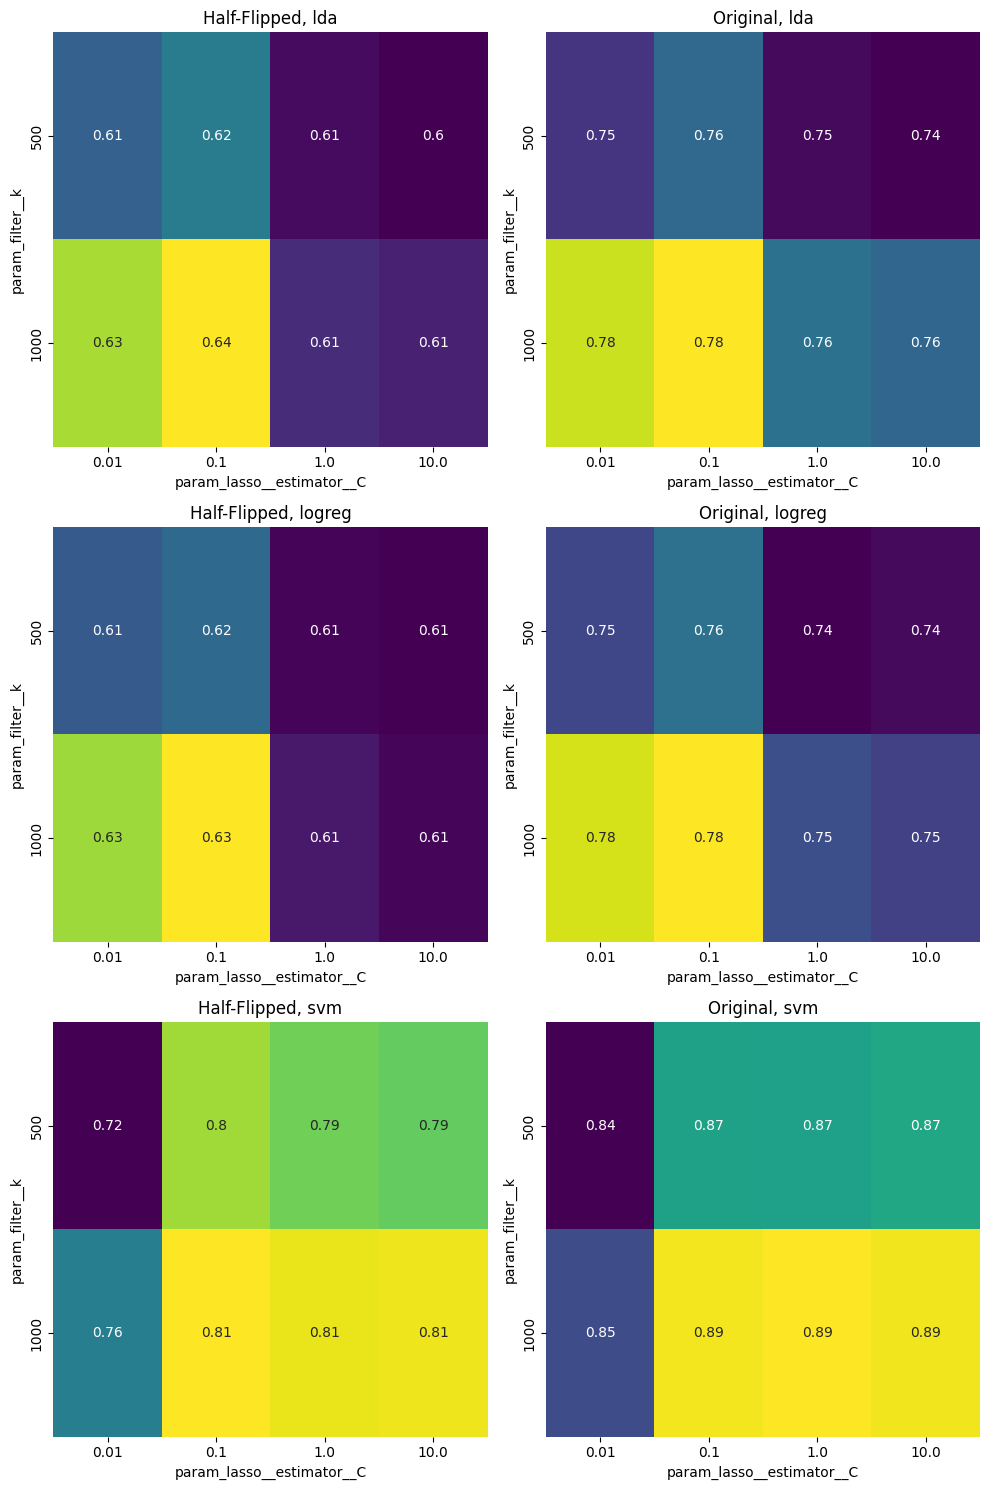

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(10,15)
)

#Get these to show Half-Flipped vs Normal
axes = axes.flatten(order="F")

for ax, (name, result) in zip(axes, grouped_results):
    pivot = result.pivot_table(
        values='mean_test_score',
        index='param_filter__k',
        columns='param_lasso__estimator__C'
    )


    sns.heatmap(pivot, annot=True, cmap="viridis", cbar=False, ax=ax)
    ax.set_title(f"{name[0]}, {name[1]}")
    ax.set_label("Lasso C")
    ax.set_label("Number of Selected Features (k)")

plt.tight_layout()
plt.show()

### Import Pixels (SEED=42)

In [ ]:
selected_pix = pd.read_csv("./results_seed42/P2.02_selected_pixels.csv", sep=",")
groups = selected_pix.groupby(['dataset','classifier'])


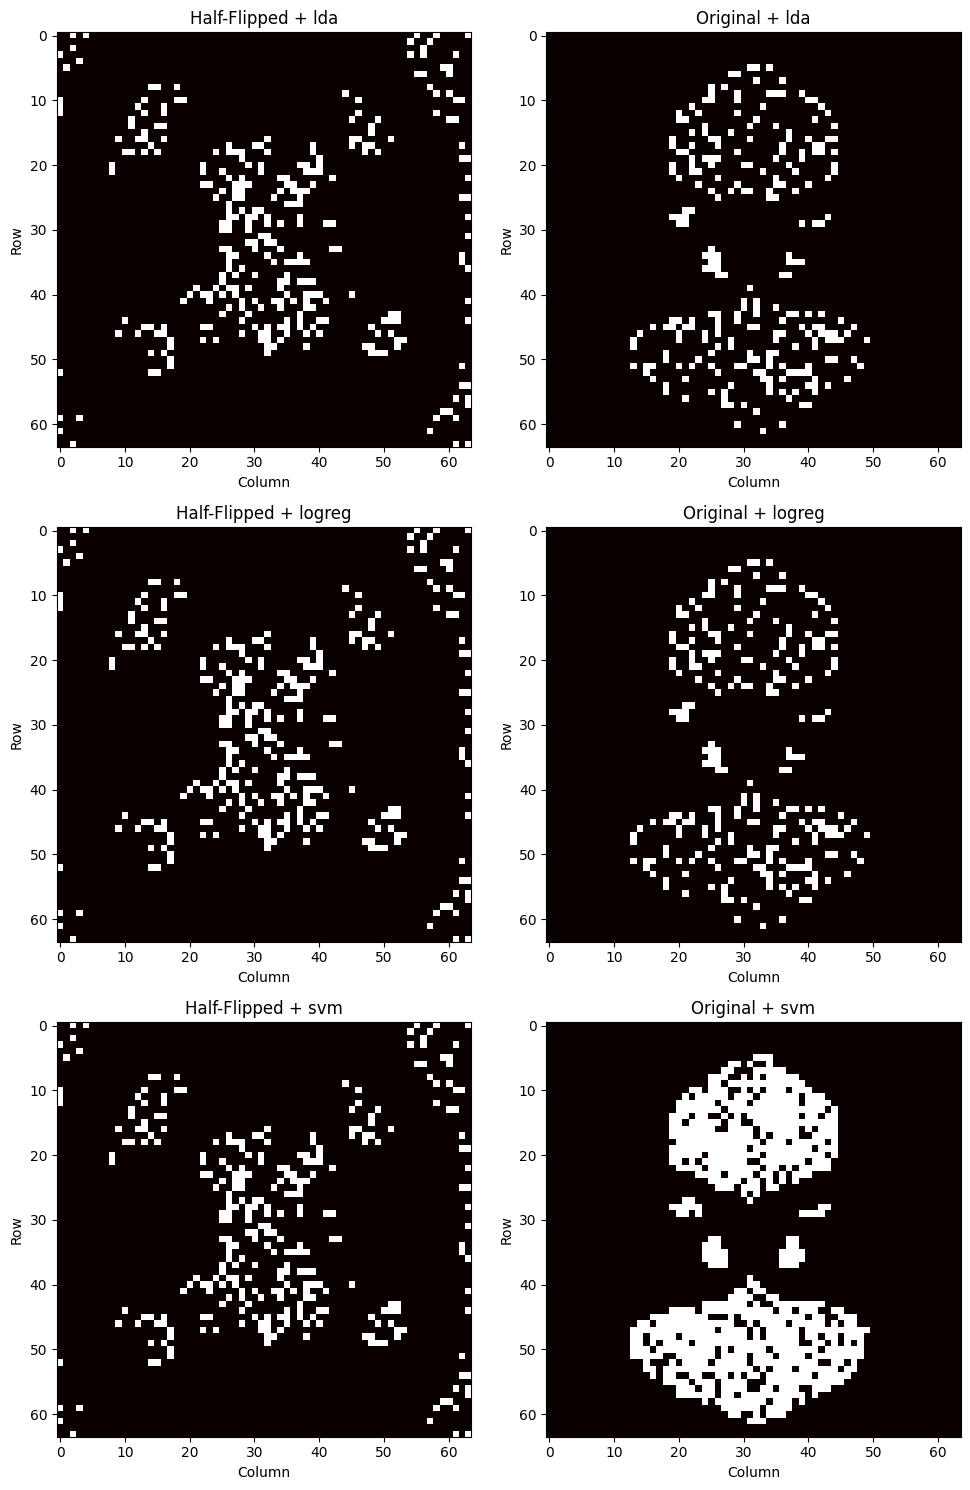

In [ ]:
n_groups = len(groups)

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(10,15)
)

#Get these to show Half-Flipped vs Normal
axes = axes.flatten(order="F")

pixel_graphs = []

for ax, ((dataset, classifier), group) in zip(axes, groups):

    # Empty image
    img = np.zeros((64,64))

    # Fill selected pixels
    for _, row in group.iterrows():
        r = int(row['row'])
        c = int(row['col'])

        # Selection Count Should be 1 if selected
        img[r, c] = 1

    pixel_graphs.append(img)

    # Display image
    ax.imshow(img, cmap='hot')

    ax.set_title(f"{dataset} + {classifier}")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

plt.tight_layout()
plt.show()


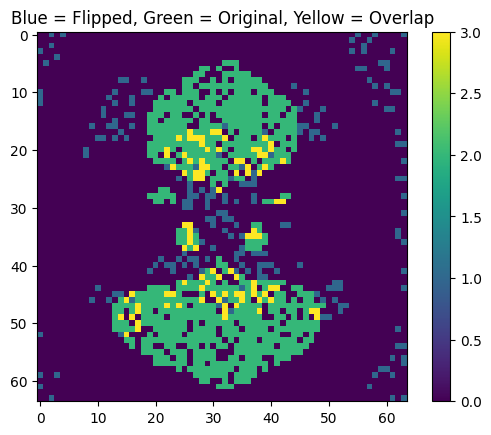

In [ ]:
plt.imshow(pixel_graphs[0] + 2 * pixel_graphs[5], cmap="viridis" )
plt.title("Blue = Flipped, Green = Original, Yellow = Overlap")
plt.colorbar()
plt.show()

pixel_graphs.append(pixel_graphs[0] + 2 * pixel_graphs[3])
pixel_graphs.append(pixel_graphs[1] + 2 * pixel_graphs[4])
pixel_graphs.append(pixel_graphs[2] + 2 * pixel_graphs[5])

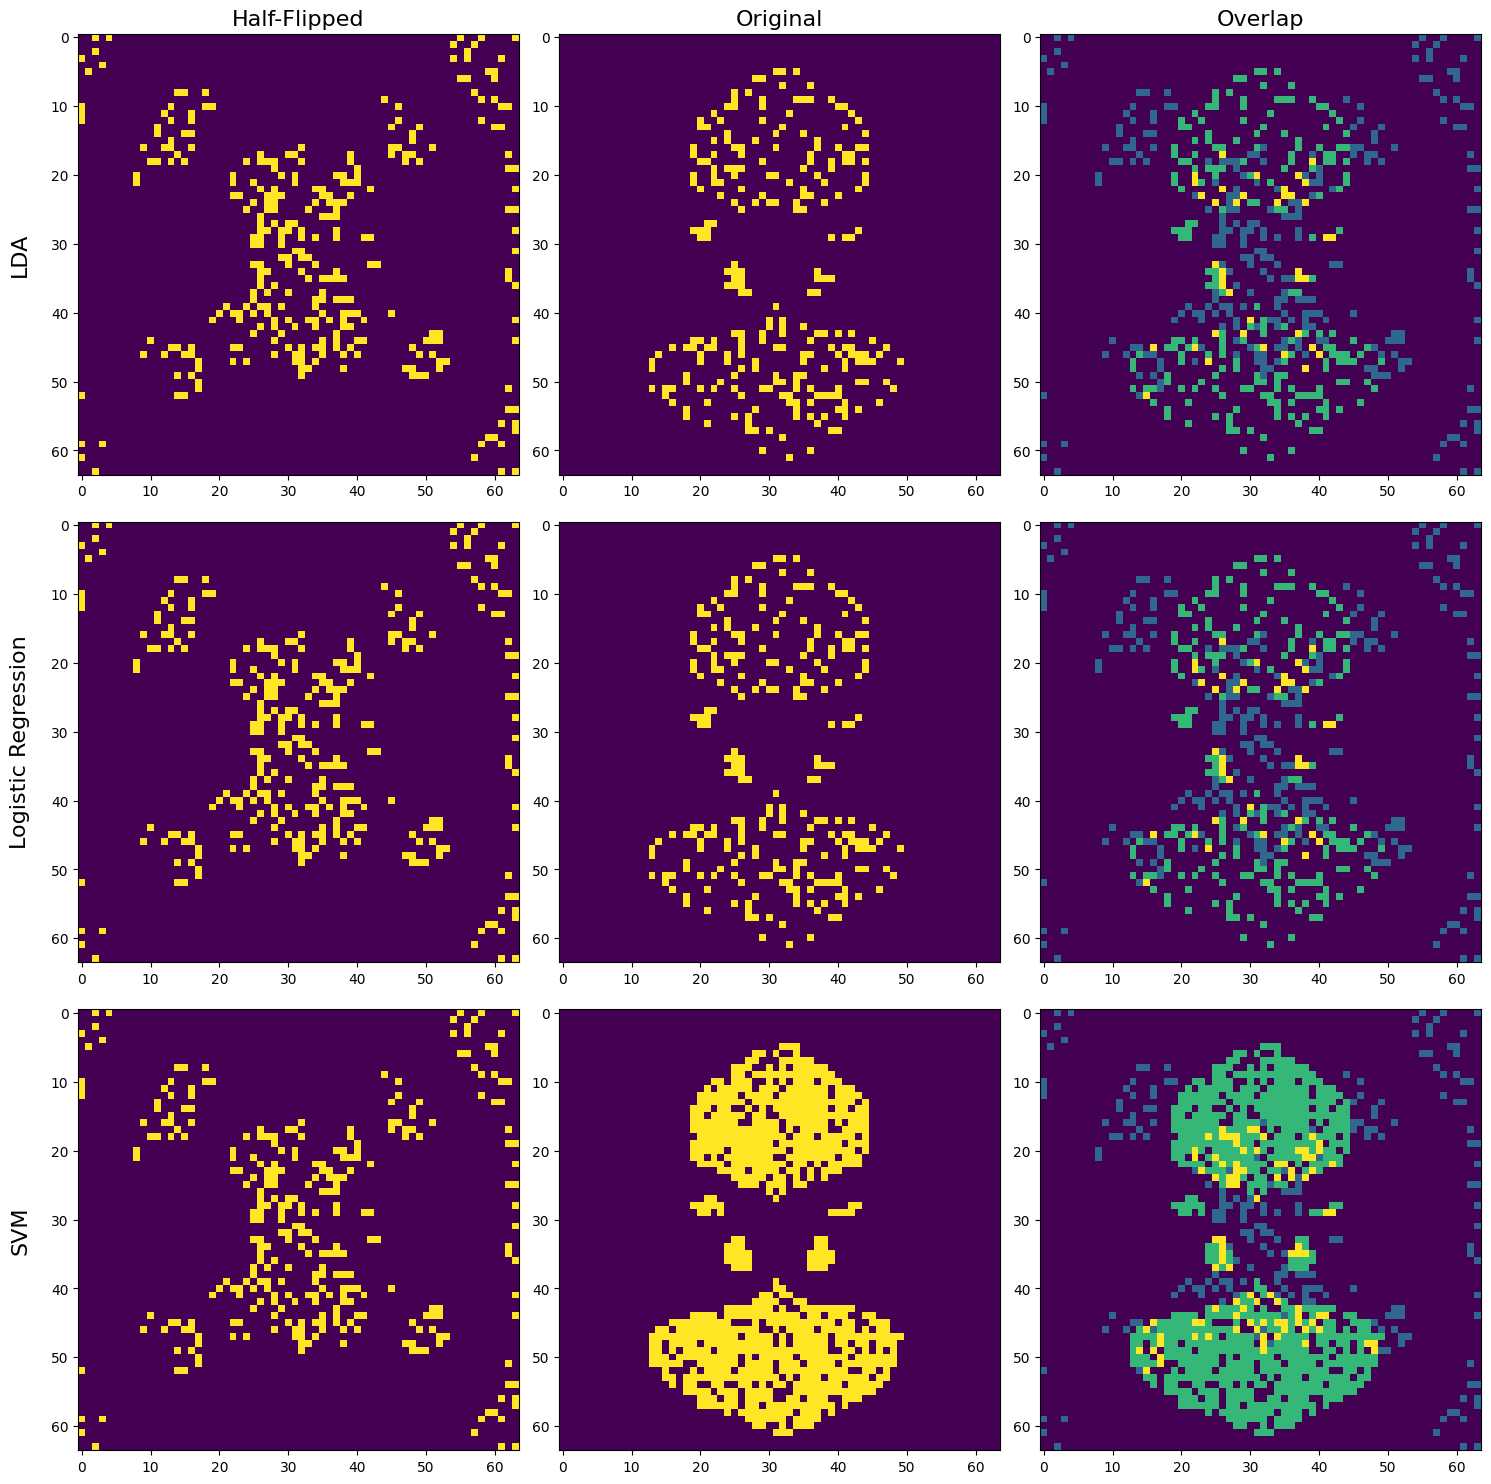

In [ ]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15,15)
)

#Get these to show Half-Flipped vs Normal
axes = axes.flatten(order="F")


for ax, img in zip(axes, pixel_graphs):

    # Display image
    ax.imshow(img, cmap='viridis')


column_titles = ["Half-Flipped", "Original", "Overlap"]

for ax, title in zip([axes[0], axes[3], axes[6]], column_titles):
    ax.set_title(title, fontsize=16)

row_titles = ["LDA", "Logistic Regression", "SVM"]

for ax, title in zip([axes[0], axes[1], axes[2]], row_titles):
    ax.set_ylabel(title, fontsize=16, rotation=90, labelpad=15)

plt.tight_layout()
plt.show()

In [ ]:
def print_selected_pix(seed):
    selected_pix = pd.read_csv(f"./results_seed{seed}/P2.02_selected_pixels.csv", sep=",")
    groups = selected_pix.groupby(['dataset','classifier'])

    pixel_graphs = []

    for (dataset, classifier), group in groups:

        # Empty image
        img = np.zeros((64,64))

        # Fill selected pixels
        for _, row in group.iterrows():
            r = int(row['row'])
            c = int(row['col'])

            # Selection Count Should be 1 if selected
            img[r, c] = 1

        pixel_graphs.append(img)

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(10,16)
    )

    #Get these to show Half-Flipped vs Normal
    axes = axes.flatten(order="F")


    for ax, img in zip(axes, pixel_graphs):

        # Display image
        ax.imshow(img, cmap='hot')


    column_titles = ["Half-Flipped", "Original"]

    for ax, title in zip([axes[0], axes[3]], column_titles):
        ax.set_title(title, fontsize=16)

    row_titles = ["LDA", "Logistic Regression", "SVM"]

    for ax, title in zip([axes[0], axes[1], axes[2]], row_titles):
        ax.set_ylabel(title, fontsize=16, rotation=90, labelpad=10)
    plt.suptitle(f"Seed {seed}", fontsize=24)
    plt.tight_layout()
    plt.show()

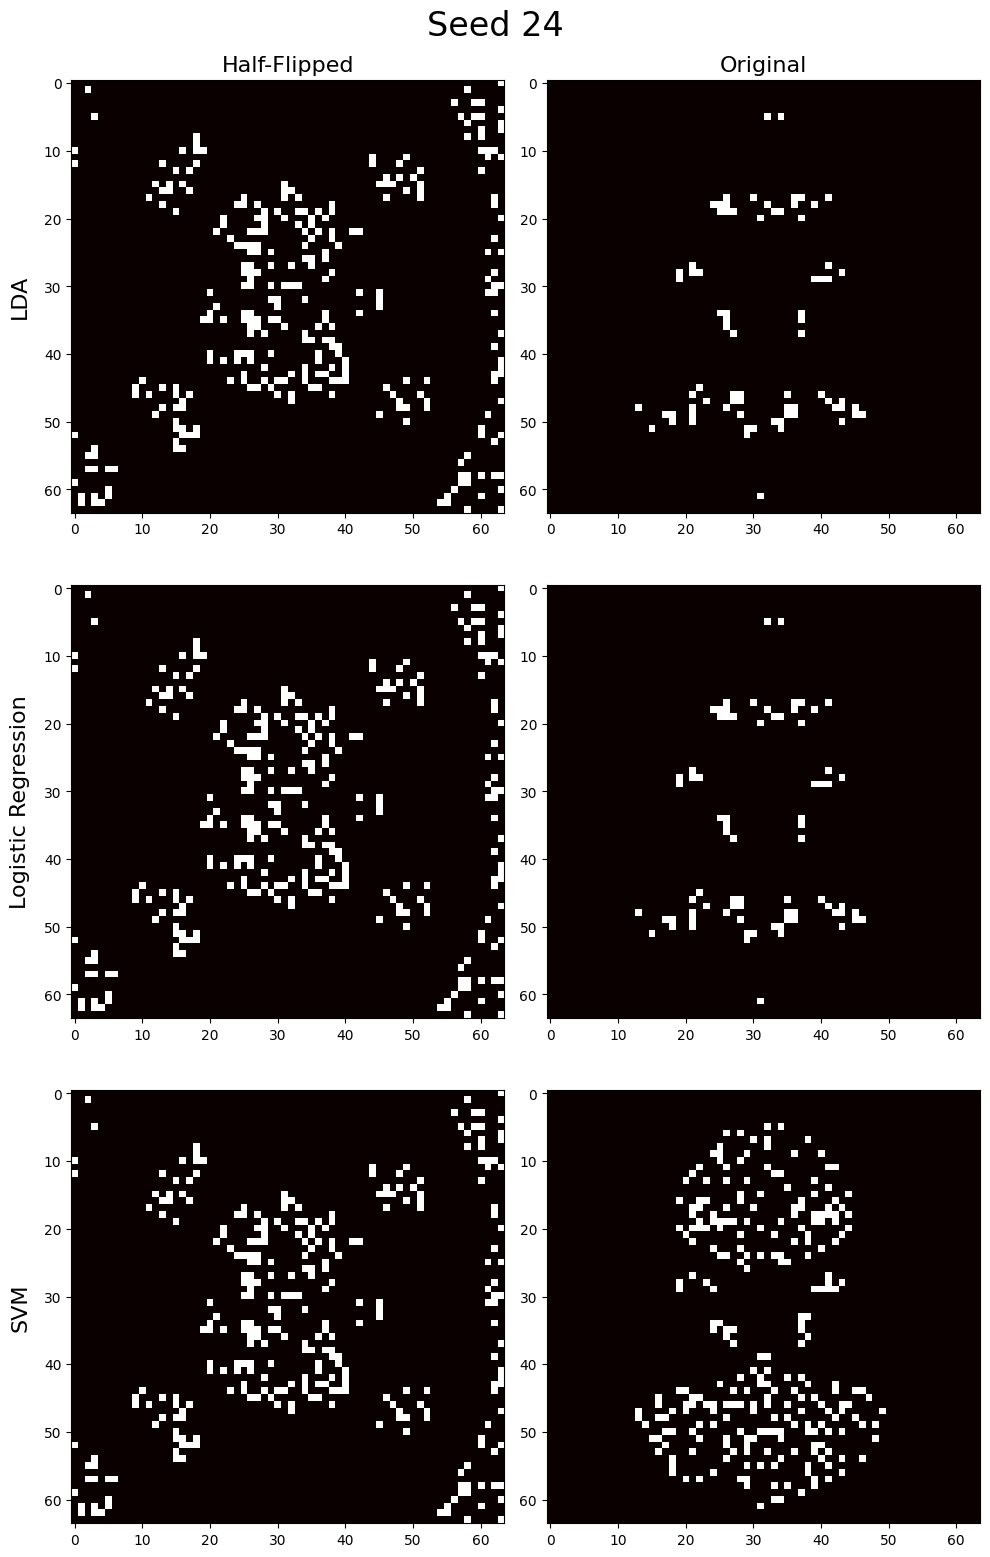

In [ ]:
print_selected_pix(24)

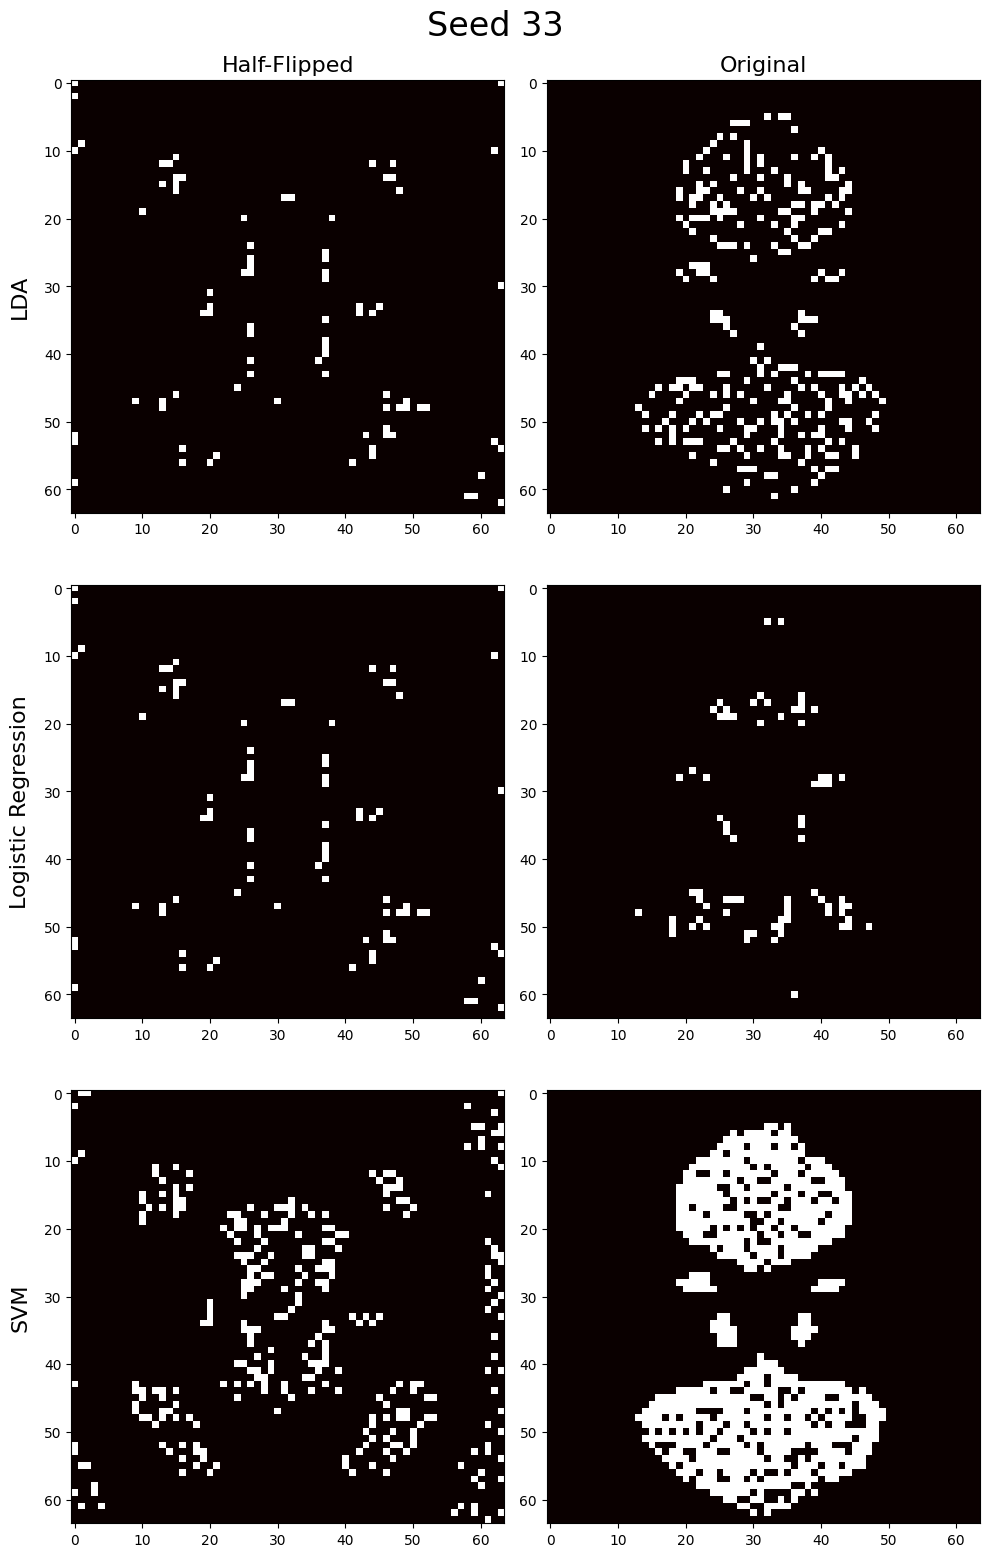

In [ ]:
print_selected_pix(33)

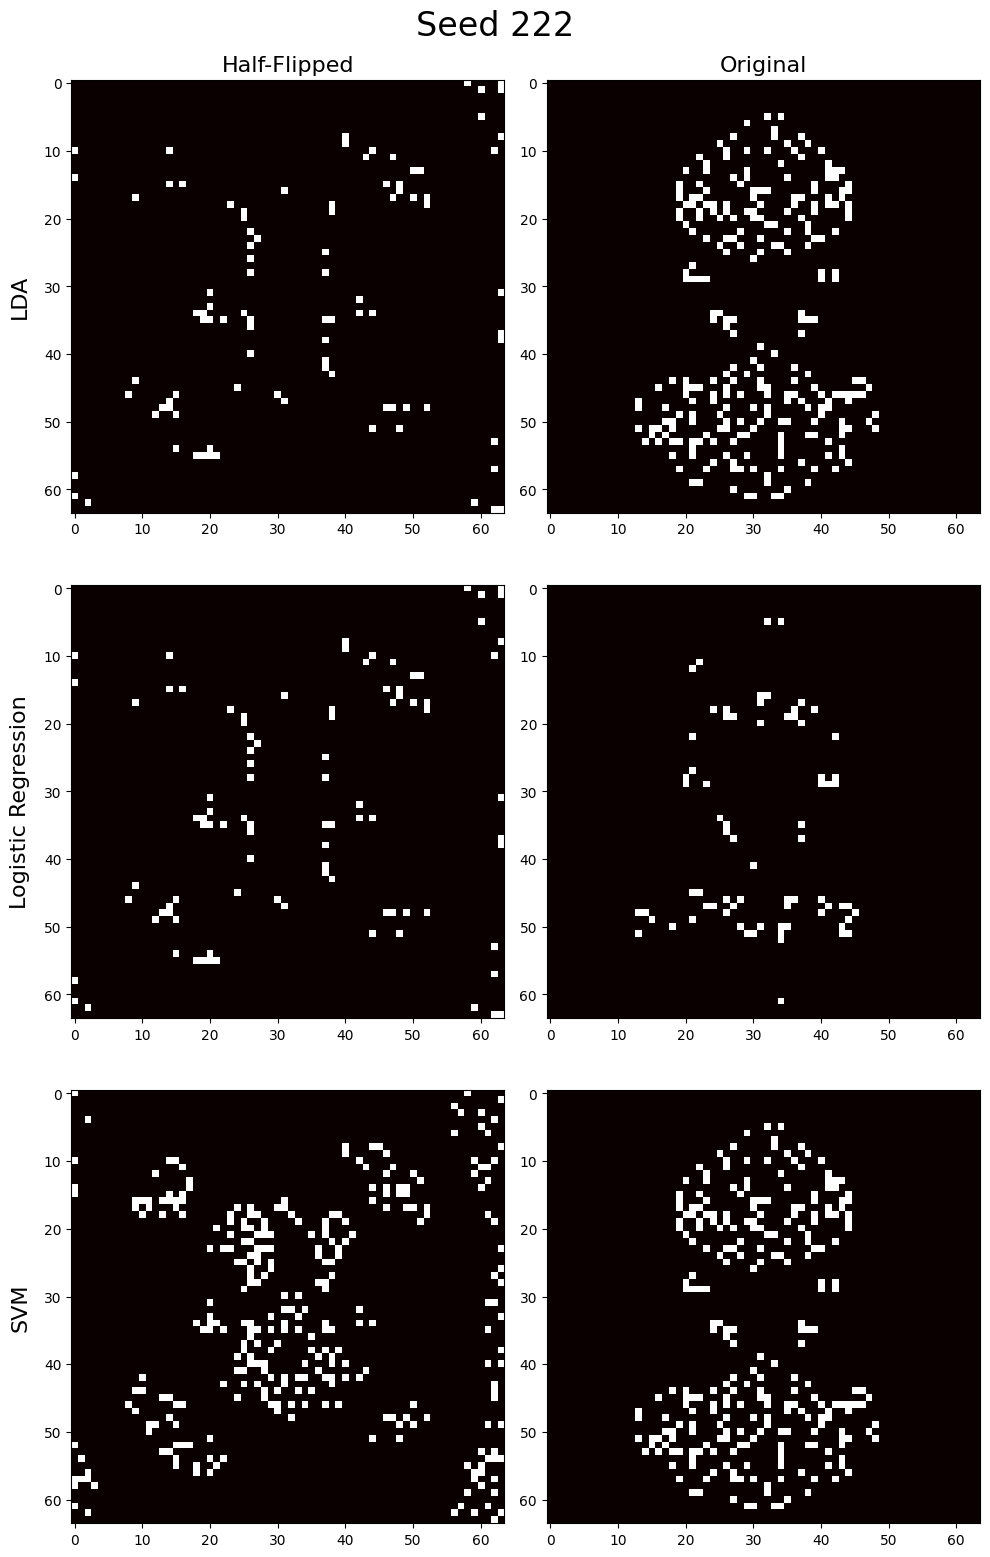

In [ ]:
print_selected_pix(222)